In [ ]:
# !pip install geopandas pyogrio shapely fiona

   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.5 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.5 MB 1.5 MB/s eta 0:00:16
   --- ------------------------------------ 1.8/24.5 MB 2.0 MB/s eta 0:00:12
   --- ------------------------------------ 2.4/24.5 MB 2.1 MB/s eta 0:00:11
   ----- ---------------------------------- 3.1/24.5 MB 2.3 MB/s eta 0:00:10
   ----- ---------------------------------- 3.4/24.5 MB 2.3 MB/s eta 0:00:10
   ------ --------------------------------- 3.7/24.5 MB 2.0 MB/s eta 0:00:11
   ------ --------------------------------- 3.9/24.5 MB 1.9 MB/s eta 0:00:11
   ------- -------------------------------- 4.5/24.5 MB 2.0 MB/s eta 0:00:11
   ------- -------------------------------- 4.5/24.5 MB 2.0 MB/s eta 0:00:11
   -------- ---------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Test Telangana:


FIRST 5 ROWS:
   OBJECTID   STATE_UT STATE_LGD  DISTRICT Dist_LGD      Sub_dist Subdis_LGD  \
0         1  TELANGANA        36  ADILABAD      532         TAMSI      04305   
1         2  TELANGANA        36  ADILABAD      532    TALAMADUGU      04309   
2         3  TELANGANA        36  ADILABAD      532  BAZARHATNOOR      04323   
3         4  TELANGANA        36  ADILABAD      532        UTNOOR      04321   
4         5  TELANGANA        36  ADILABAD      532        ICHODA      04322   

  Subdis_Typ     Vill_name Vill_cat Vill_LGD    Shape_Leng    Shape_Area  \
0     MANDAL       Tamsi-B    RURAL   568972  14012.213268  1.113004e+07   
1     MANDAL   Kuchalapoor    RURAL   569123  20988.635789  1.970577e+07   
2     MANDAL        Kandli    RURAL   569666  11355.714274  5.078041e+06   
3     MANDAL  Danthanpalle    RURAL   569590  19432.660561  1.958206e+07   
4     MANDAL         Gundi    RURAL   569625   5623.849001  1.979551e+06   

                                            geo

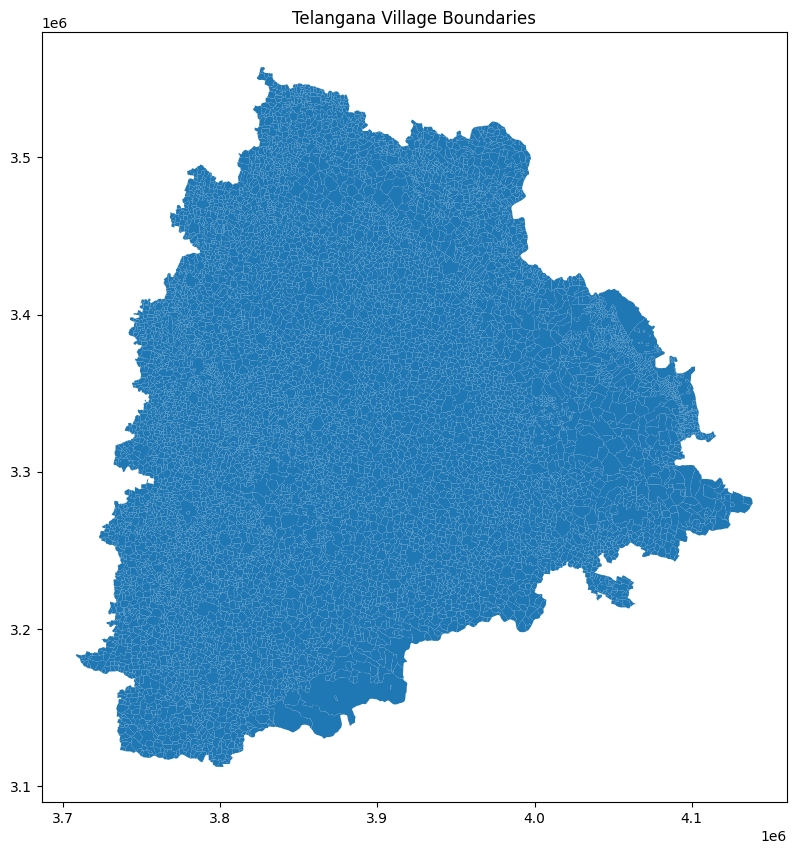

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Telangana shapefile
gdf = gpd.read_file(
    r"D:\Village_Nighttime\village-nightTime\Data\Telangana\TELANGANA.shp"
)

# Basic inspection
print("\nFIRST 5 ROWS:")
print(gdf.head())

print("\nCOLUMNS:")
print(gdf.columns)

print("\nCRS:")
print(gdf.crs)

print("\nSHAPE:")
print(gdf.shape)

# Plot map
gdf.plot(figsize=(10, 10))

plt.title("Telangana Village Boundaries")
plt.show()

State-wise village boundary shapefiles were cleaned, standardized, and transformed into the `EPSG:4326` coordinate system using Python GeoPandas. Invalid geometries and inconsistent schemas were corrected to ensure compatibility with :contentReference[oaicite:0]{index=0} for village-level night-time light extraction.

In [15]:
import geopandas as gpd
import os

base_path = r"D:\Village_Nighttime\village-nightTime\Data"
output_path = r"D:\Village_Nighttime\village-nightTime\Output data\gee_ready"

os.makedirs(output_path, exist_ok=True)

states = os.listdir(base_path)

for state in states:

    state_folder = os.path.join(base_path, state)

    if not os.path.isdir(state_folder):
        continue

    print("\n==============================")
    print("PROCESSING:", state)
    print("==============================")

    shp_files = [f for f in os.listdir(state_folder) if f.endswith(".shp")]

    if len(shp_files) == 0:
        print("No shapefile found:", state)
        continue

    shp_path = os.path.join(state_folder, shp_files[0])

    try:
        gdf = gpd.read_file(shp_path)

        print("Original CRS:", gdf.crs)

        # -----------------------------
        # FIX CRS
        # -----------------------------
        if gdf.crs is None:
            print("No CRS found. Forcing EPSG:7755 assumption")
            gdf = gdf.set_crs("EPSG:7755", allow_override=True)

        gdf = gdf.to_crs("EPSG:4326")

        # -----------------------------
        # FIX GEOMETRY
        # -----------------------------
        gdf["geometry"] = gdf["geometry"].buffer(0)

        before = len(gdf)
        gdf = gdf[gdf.is_valid & ~gdf.is_empty]
        after = len(gdf)

        print(f"Invalid removed: {before - after}")
        print(f"Final rows: {after}")

        # -----------------------------
        # SAVE CLEAN FILE
        # -----------------------------
        out_file = os.path.join(output_path, f"{state}_clean.geojson")

        gdf.to_file(out_file, driver="GeoJSON")

        print("Saved:", out_file)

    except Exception as e:
        print("FAILED:", state)
        print("ERROR:", str(e))


PROCESSING: Andhra Pradesh
Original CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Invalid removed: 0
Final rows: 18050
Saved: D:\Village_Nighttime\village-nightTime\Output data\gee_ready\Andhra Pradesh_clean.geojson

PROCESSING: Gujarat
Original CRS: EPSG:3395
Invalid removed: 0
Final rows: 19824
Saved: D:\Village_Nighttime\village-nightTime\Output data\gee_ready\Gujarat_clean.geojson

PROCESSING: Karnataka
Original CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID[

In [16]:
import geopandas as gpd
import os

folder = r"D:\Village_Nighttime\village-nightTime\Output data\gee_ready"

files = [f for f in os.listdir(folder) if f.endswith(".geojson")]

for f in files:
    path = os.path.join(folder, f)

    print("\n========================")
    print("FILE:", f)
    print("========================")

    gdf = gpd.read_file(path)

    print("CRS:", gdf.crs)
    print("ROWS:", len(gdf))
    print("COLUMNS:", list(gdf.columns))

    print("VALID GEOMETRIES:", gdf.is_valid.sum(), "/", len(gdf))


FILE: Andhra Pradesh_clean.geojson
CRS: EPSG:4326
ROWS: 18050
COLUMNS: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'District', 'Dist_LGD', 'Sub_dist', 'Subdis_LGD', 'Subdis_Typ', 'Vill_name', 'Vill_Cat', 'Vill_LGD', 'Shape_Leng', 'Shape_Area', 'geometry']
VALID GEOMETRIES: 18050 / 18050

FILE: Gujarat_clean.geojson
CRS: EPSG:4326
ROWS: 19824
COLUMNS: ['OBJECTID', 'STATE_UT', 'Shape_Leng', 'Shape_Area', 'State_LGD', 'District', 'Dist_LGD', 'Sub_dist', 'Subdis_LGD', 'Subdis_Typ', 'Vill_name', 'Vill_Cat', 'Vill_LGD', 'geometry']
VALID GEOMETRIES: 19824 / 19824

FILE: Karnataka_clean.geojson
CRS: EPSG:4326
ROWS: 31024
COLUMNS: ['OBJECTID', 'STATE_UT', 'State_LGD', 'District', 'Dist_LGD', 'Sub_dist', 'Subdis_LGD', 'Subdis_Typ', 'Vill_name', 'Vill_Cat', 'Vill_LGD', 'Shape_Leng', 'Shape_Area', 'geometry']
VALID GEOMETRIES: 31024 / 31024

FILE: Rajasthan_clean.geojson
CRS: EPSG:4326
ROWS: 46814
COLUMNS: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'District', 'Dist_LGD', 'Sub_dist', 'Subdis_LGD', 'Subdis_

In [20]:
print(merged.columns)

Index(['OBJECTID', 'STATE_UT', 'STATE_LGD', 'District', 'Dist_LGD', 'Sub_dist',
       'Subdis_LGD', 'Subdis_Typ', 'Vill_name', 'Vill_Cat', 'Vill_LGD',
       'Shape_Leng', 'Shape_Area', 'geometry', 'State_LGD', 'Subdist',
       'DISTRICT', 'Vill_cat', 'SHAPE_Leng', 'SHAPE_Area'],
      dtype='object')


In [23]:
import geopandas as gpd
import pandas as pd
import os

base_folder = r"D:\Village_Nighttime\village-nightTime\Output data\gee_ready"

files = [f for f in os.listdir(base_folder) if f.endswith(".geojson")]

def clean_gdf(gdf):

    # normalize column names
    gdf.columns = [c.lower().strip() for c in gdf.columns]

    # remove duplicate columns
    gdf = gdf.loc[:, ~gdf.columns.duplicated()]

    # unify state field
    if "state" not in gdf.columns:
        if "state_ut" in gdf.columns:
            gdf["state"] = gdf["state_ut"]
        elif "state_lgd" in gdf.columns:
            gdf["state"] = gdf["state_lgd"]
        else:
            gdf["state"] = None

    # standardize state labels
    gdf["state"] = (
        gdf["state"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # unify district
    if "district" not in gdf.columns:
        if "dist_lgd" in gdf.columns:
            gdf["district"] = gdf["dist_lgd"]
        else:
            gdf["district"] = None

    # unify subdistrict
    if "subdistrict" not in gdf.columns:
        if "sub_dist" in gdf.columns:
            gdf["subdistrict"] = gdf["sub_dist"]
        elif "subdist" in gdf.columns:
            gdf["subdistrict"] = gdf["subdist"]
        else:
            gdf["subdistrict"] = None

    # unify village
    if "village" not in gdf.columns:
        gdf["village"] = gdf.get("vill_name", None)

    # unify village id
    if "village_lgd" not in gdf.columns:
        gdf["village_lgd"] = gdf.get("vill_lgd", None)

    # unify area
    if "area" not in gdf.columns:
        if "shape_area" in gdf.columns:
            gdf["area"] = gdf["shape_area"]
        elif "cal_area" in gdf.columns:
            gdf["area"] = gdf["cal_area"]
        else:
            gdf["area"] = None

    # keep only required columns
    keep = ["state", "district", "subdistrict", "village", "village_lgd", "area", "geometry"]

    for c in keep:
        if c not in gdf.columns:
            gdf[c] = None

    return gdf[keep]

all_data = []

for f in files:

    path = os.path.join(base_folder, f)
    gdf = gpd.read_file(path)

    # CRS fix
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")

    # geometry cleanup
    gdf["geometry"] = gdf["geometry"].buffer(0)
    gdf = gdf[gdf.is_valid & ~gdf.is_empty]

    gdf = clean_gdf(gdf)

    all_data.append(gdf)

merged = gpd.GeoDataFrame(pd.concat(all_data, ignore_index=True), crs="EPSG:4326")

# final normalization check
print("TOTAL VILLAGES:", len(merged))
print(merged["state"].value_counts())
print(merged.columns)

TOTAL VILLAGES: 289831
state
UTTAR PRADESH     104963
RAJASTHAN          46814
WEST BENGAL        41322
KARNATAKA          31024
GUJARAT            19824
ANDHRA PRADESH     18050
TAMIL NADU         17379
TELANGANA          10455
Name: count, dtype: int64
Index(['state', 'district', 'subdistrict', 'village', 'village_lgd', 'area',
       'geometry'],
      dtype='object')


In [24]:
import geopandas as gpd
import os

input_base = r"D:\Village_Nighttime\village-nightTime\Data"
output_base = r"D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES"

os.makedirs(output_base, exist_ok=True)

states = os.listdir(input_base)

def clean_for_gee(gdf):

    # force CRS consistency
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    gdf = gdf.to_crs("EPSG:4326")

    # fix invalid geometries
    gdf["geometry"] = gdf["geometry"].buffer(0)
    gdf = gdf[gdf.is_valid & ~gdf.is_empty]

    # standardize minimal schema (DO NOT overcomplicate for GEE upload)
    keep_cols = [c for c in gdf.columns if c.lower() in [
        "state_ut", "state_lgd",
        "district", "dist_lgd",
        "sub_dist", "subdist",
        "vill_name", "vill_lgd",
        "shape_area", "cal_area",
        "geometry"
    ]]

    gdf = gdf[keep_cols]

    return gdf


for state in states:

    state_path = os.path.join(input_base, state)

    shp_files = [f for f in os.listdir(state_path) if f.endswith(".shp")]

    if not shp_files:
        print("SKIP:", state)
        continue

    shp_path = os.path.join(state_path, shp_files[0])

    print("PROCESSING:", state)

    gdf = gpd.read_file(shp_path)

    gdf = clean_for_gee(gdf)

    # output folder per state
    out_folder = os.path.join(output_base, state)
    os.makedirs(out_folder, exist_ok=True)

    out_file = os.path.join(out_folder, f"{state}.shp")

    gdf.to_file(out_file)

    print("SAVED:", out_file)

PROCESSING: Andhra Pradesh
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Andhra Pradesh\Andhra Pradesh.shp
PROCESSING: Gujarat
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Gujarat\Gujarat.shp
PROCESSING: Karnataka
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Karnataka\Karnataka.shp
PROCESSING: Rajasthan
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Rajasthan\Rajasthan.shp
PROCESSING: Tamil Nadu
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Tamil Nadu\Tamil Nadu.shp
PROCESSING: Telangana
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Telangana\Telangana.shp
PROCESSING: Uttar Pradesh
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\Uttar Pradesh\Uttar Pradesh.shp
PROCESSING: West Bengal
SAVED: D:\Village_Nighttime\village-nightTime\CLEAN_SHAPEFILES\West Bengal\West Bengal.shp


## Night-Time Light Dataset Cleaning and Feature Engineering

The extracted village-level VIIRS night-time luminosity dataset was cleaned and standardized using Python Pandas. Irrelevant attributes were removed, administrative variables were renamed into a consistent schema, and a compact analytical dataset was created.

Additional indicators were then constructed to capture temporal and spatial changes in luminosity, including:
- absolute night-light growth,
- proportional growth rate,
- logarithmic growth transformation,
- and village-level light intensity density.

Finally, descriptive statistical analysis was conducted to examine the distribution, variability, and presence of outliers in the luminosity indicators before further econometric and spatial analysis.

In [25]:
import pandas as pd

df = pd.read_csv(r"C:\Users\renu\Downloads\india_village_growth_safe_v2.csv")

print(df.columns.tolist())
print(df.head())

C:\Users\renu\AppData\Local\Temp\ipykernel_32516\4149118863.py:3: DtypeWarning: Columns (1,2,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\renu\Downloads\india_village_growth_safe_v2.csv")


['system:index', 'DISTRICT', 'Dist_LGD', 'STATE_LGD', 'STATE_UT', 'Shape_Area', 'Sub_dist', 'Vill_LGD', 'Vill_name', 'growth', 'light_2021', 'light_2025', 'mean', 'state', '.geo']
                         system:index  DISTRICT Dist_LGD  STATE_LGD  \
0  1_1_1_1_1_1_2_00000000000000000174  ADILABAD      532       36.0   
1  1_1_1_1_1_1_2_0000000000000000007b  ADILABAD      532       36.0   
2  1_1_1_1_1_1_2_00000000000000000173  ADILABAD      532       36.0   
3  1_1_1_1_1_1_2_00000000000000000172  ADILABAD      532       36.0   
4  1_1_1_1_1_1_2_00000000000000000171  ADILABAD      532       36.0   

    STATE_UT    Shape_Area  Sub_dist Vill_LGD  Vill_name    growth  \
0  TELANGANA  1.892687e+07  BHEEMPUR   568945  Karanji-T  0.169304   
1  TELANGANA  7.282992e+06  BHEEMPUR   568946     Gubidi  0.116712   
2  TELANGANA  1.073560e+07  BHEEMPUR   568947   Gomuthri  0.077465   
3  TELANGANA  5.290802e+06  BHEEMPUR   568948  Antergaon  0.197268   
4  TELANGANA  2.885838e+07  BHEEMPUR   5689

In [26]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\renu\Downloads\india_village_growth_safe_v2.csv",
    low_memory=False
)

# KEEP ONLY USEFUL COLUMNS
df = df[
    [
        "STATE_UT",
        "DISTRICT",
        "Sub_dist",
        "Vill_LGD",
        "Vill_name",
        "Shape_Area",
        "light_2021",
        "light_2025",
        "growth"
    ]
]

# OPTIONAL RENAME
df.columns = [
    "state",
    "district",
    "subdistrict",
    "village_lgd",
    "village",
    "area",
    "light_2021",
    "light_2025",
    "growth"
]

print(df.head())
print(df.shape)


       state  district subdistrict village_lgd    village          area  \
0  TELANGANA  ADILABAD    BHEEMPUR      568945  Karanji-T  1.892687e+07   
1  TELANGANA  ADILABAD    BHEEMPUR      568946     Gubidi  7.282992e+06   
2  TELANGANA  ADILABAD    BHEEMPUR      568947   Gomuthri  1.073560e+07   
3  TELANGANA  ADILABAD    BHEEMPUR      568948  Antergaon  5.290802e+06   
4  TELANGANA  ADILABAD    BHEEMPUR      568949     Arli-T  2.885838e+07   

   light_2021  light_2025    growth  
0    0.439301    0.608605  0.169304  
1    0.345061    0.461773  0.116712  
2    0.466675    0.544140  0.077465  
3    0.392569    0.589837  0.197268  
4    0.436484    0.559642  0.123158  
(272452, 9)


In [27]:
# SAVE CLEAN DATASET
df.to_csv(
    r"C:\Users\renu\Downloads\india_village_growth_clean.csv",
    index=False
)

print("CLEAN FILE SAVED")

CLEAN FILE SAVED


In [28]:
df["growth_rate"] = (
    (df["light_2025"] - df["light_2021"])
    / (df["light_2021"] + 0.01)
)

In [29]:
import numpy as np

df["log_growth"] = (
    np.log1p(df["light_2025"])
    - np.log1p(df["light_2021"])
)

In [30]:
df["light_density_2025"] = (
    df["light_2025"] / df["area"]
)

In [31]:
print(df.head())

       state  district subdistrict village_lgd    village          area  \
0  TELANGANA  ADILABAD    BHEEMPUR      568945  Karanji-T  1.892687e+07   
1  TELANGANA  ADILABAD    BHEEMPUR      568946     Gubidi  7.282992e+06   
2  TELANGANA  ADILABAD    BHEEMPUR      568947   Gomuthri  1.073560e+07   
3  TELANGANA  ADILABAD    BHEEMPUR      568948  Antergaon  5.290802e+06   
4  TELANGANA  ADILABAD    BHEEMPUR      568949     Arli-T  2.885838e+07   

   light_2021  light_2025    growth  growth_rate  log_growth  \
0    0.439301    0.608605  0.169304     0.376817    0.111210   
1    0.345061    0.461773  0.116712     0.328711    0.083211   
2    0.466675    0.544140  0.077465     0.162511    0.051469   
3    0.392569    0.589837  0.197268     0.490023    0.132481   
4    0.436484    0.559642  0.123158     0.275839    0.082258   

   light_density_2025  
0        3.215560e-08  
1        6.340428e-08  
2        5.068555e-08  
3        1.114834e-07  
4        1.939270e-08  


In [32]:
df[
    [
        "light_2021",
        "light_2025",
        "growth",
        "growth_rate",
        "log_growth",
        "light_density_2025"
    ]
].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])

,light_2021,light_2025,growth,growth_rate,log_growth,light_density_2025
count,272452.000000,272452.000000,272452.000000,272452.000000,272452.000000,2.311300e+05
mean,1.117036,1.637151,0.520115,0.479015,0.170322,2.064055e-06
std,1.518462,2.320008,1.344359,2.421248,0.190539,1.648506e-05
min,0.000000,0.000000,-45.456645,-0.949978,-2.493788,0.000000e+00
1%,0.317084,0.375250,-0.213072,-0.165664,-0.091883,1.573072e-08
5%,0.403276,0.483389,-0.018685,-0.024325,-0.010597,4.088783e-08
25%,0.589560,0.742906,0.108273,0.165361,0.063940,1.595582e-07
50%,0.811669,1.091488,0.248797,0.318428,0.129277,4.609142e-07
75%,1.167040,1.717805,0.555138,0.540147,0.236042,1.387192e-06
95%,2.548543,4.197193,1.731351,1.095978,0.472308,7.034129e-06


## Outlier Treatment and Distribution Diagnostics

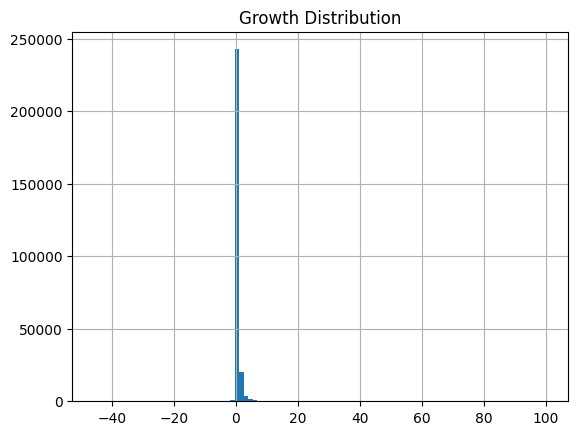

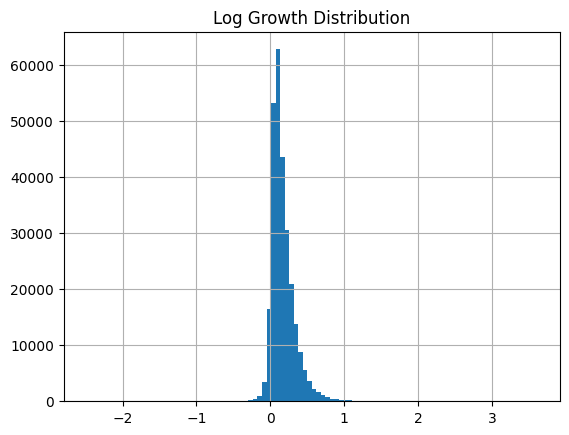

In [33]:
import matplotlib.pyplot as plt

df["growth"].hist(bins=100)
plt.title("Growth Distribution")
plt.show()

df["log_growth"].hist(bins=100)
plt.title("Log Growth Distribution")
plt.show()

In [34]:
lower = df["growth"].quantile(0.01)
upper = df["growth"].quantile(0.99)

df["growth_winsor"] = df["growth"].clip(lower, upper)

In [35]:
df.groupby("state")["light_2025"].mean().sort_values()

state
ANDHRA PRADESH     0.955463
RAJASTHAN          1.116979
TELANGANA          1.354250
WEST BENGAL        1.482467
KARNATAKA          1.682471
UTTAR PRADESH      1.960160
GUJARAT            2.174632
West Bengal       41.806158
Name: light_2025, dtype: float64

In [36]:
df["state"] = (
    df["state"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [37]:
df.groupby("state")["light_2025"].mean().sort_values()

state
ANDHRA PRADESH    0.955463
RAJASTHAN         1.116979
TELANGANA         1.354250
WEST BENGAL       1.483443
KARNATAKA         1.682471
UTTAR PRADESH     1.960160
GUJARAT           2.174632
Name: light_2025, dtype: float64

In [38]:
# growth by state
df.groupby("state")["growth"].mean().sort_values()

# median is safer than mean
df.groupby("state")["light_2025"].median().sort_values()

# inequality within states
df.groupby("state")["light_2025"].std().sort_values()

state
ANDHRA PRADESH    1.337656
RAJASTHAN         1.416838
UTTAR PRADESH     1.952658
WEST BENGAL       2.093572
TELANGANA         2.700360
KARNATAKA         2.941846
GUJARAT           4.346724
Name: light_2025, dtype: float64

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["growth_scaled"] = scaler.fit_transform(
    df[["log_growth"]]
)

df["light_scaled"] = scaler.fit_transform(
    df[["light_2025"]]
)

df["density_scaled"] = scaler.fit_transform(
    df[["light_density_2025"]]
)

df["economic_growth_score"] = (
    0.5 * df["growth_scaled"] +
    0.3 * df["light_scaled"] +
    0.2 * df["density_scaled"]
)

In [41]:
top100 = df.sort_values(
    "economic_growth_score",
    ascending=False
).head(100)

In [42]:
top100[
    [
        "state",
        "district",
        "village",
        "economic_growth_score",
        "light_2021",
        "light_2025",
        "growth_rate"
    ]
].head(20)

,state,district,village,economic_growth_score,light_2021,light_2025,growth_rate
118383,ANDHRA PRADESH,NaN,NaN,0.596601,0.316006,10.547500,31.384328
15795,GUJARAT,NaN,AHMADABAD CANTONMENT,0.569912,0.403420,50.901845,122.147897
15847,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 19",0.561750,0.403420,48.197433,115.606340
245651,UTTAR PRADESH,NaN,Mamrezpur Al,0.557039,119.270528,219.208899,0.837843
15827,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 16",0.549603,0.403420,44.198883,105.934466
15825,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 29",0.547493,0.403420,43.462615,104.153548
15838,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 5",0.546926,0.403420,43.422944,104.057589
15826,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 17",0.546851,0.403420,43.314275,103.794735
15837,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 10",0.545690,0.403420,43.000407,103.035538
15839,GUJARAT,NaN,"AHMEDABAD MUNICIPAL CORPORATION, WARD NO: 2",0.542947,0.403420,42.226316,101.163131


In [43]:
bad_terms = [
    "MUNICIPAL",
    "CORPORATION",
    "WARD",
    "CANTONMENT",
    "CMC",
    "UDA",
    "MC"
]

pattern = "|".join(bad_terms)

df = df[
    ~df["village"]
    .str.upper()
    .str.contains(pattern, na=False)
]

In [44]:
df = df[df["light_2021"] > 0.5]

In [45]:
df["economic_growth_score"] = (
    0.6 * df["growth_scaled"] +
    0.3 * df["light_scaled"] +
    0.1 * df["density_scaled"]
)

In [46]:
top100 = df.sort_values(
    "economic_growth_score",
    ascending=False
).head(100)

In [47]:
top100[
    [
        "state",
        "district",
        "village",
        "economic_growth_score",
        "light_2021",
        "light_2025",
        "growth_rate"
    ]
].head(20)

,state,district,village,economic_growth_score,light_2021,light_2025,growth_rate
245651,UTTAR PRADESH,NaN,Mamrezpur Al,0.606186,119.270528,219.208899,0.837843
23818,GUJARAT,NaN,AMANPOR MOTA,0.589427,0.693128,33.985363,47.348788
264378,UTTAR PRADESH,NaN,Awraha Kachar Gair Abad,0.554842,1.957382,37.703840,18.169556
43620,KARNATAKA,NaN,Chikkasabbenahalli,0.545623,1.077001,28.451361,25.183376
23820,GUJARAT,NaN,NONDHANA,0.531248,0.877989,23.764279,25.773180
31061,KARNATAKA,NaN,Doddagollahalli,0.504874,1.344932,22.875286,15.890357
31030,KARNATAKA,NaN,Arishinakunte,0.498110,81.056008,143.387180,0.768894
110852,ANDHRA PRADESH,NaN,China Pandraka,0.487835,1.468854,20.819286,13.084746
203187,UTTAR PRADESH,NaN,Ghamhapur,0.486470,7.950120,49.815435,5.259382
264357,UTTAR PRADESH,NaN,Sihori Kachar Gair Abad,0.485113,1.859580,22.647514,11.119039


In [48]:
df = df[
    ~df["village"]
    .str.upper()
    .str.contains(
        "M.CORP|MUNICIPAL|CORPORATION|WARD|CANTONMENT",
        na=False
    )
]

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["growth_scaled"] = scaler.fit_transform(
    df[["log_growth"]]
)

df["light_scaled"] = scaler.fit_transform(
    df[["light_2025"]]
)

df["density_scaled"] = scaler.fit_transform(
    df[["light_density_2025"]]
)

In [50]:
df["economic_growth_score"] = (
    0.6 * df["growth_scaled"] +
    0.3 * df["light_scaled"] +
    0.1 * df["density_scaled"]
)

In [51]:
top100 = df.sort_values(
    "economic_growth_score",
    ascending=False
).head(100)

In [53]:
print(df.shape)

(230008, 17)


In [54]:
top100[
    [
        "state",
        "district",
        "village",
        "economic_growth_score",
        "light_2021",
        "light_2025",
        "growth_rate"
    ]
].head(20)

,state,district,village,economic_growth_score,light_2021,light_2025,growth_rate
23818,GUJARAT,NaN,AMANPOR MOTA,0.646351,0.693128,33.985363,47.348788
245651,UTTAR PRADESH,NaN,Mamrezpur Al,0.638736,119.270528,219.208899,0.837843
264378,UTTAR PRADESH,NaN,Awraha Kachar Gair Abad,0.608482,1.957382,37.703840,18.169556
43620,KARNATAKA,NaN,Chikkasabbenahalli,0.598853,1.077001,28.451361,25.183376
23820,GUJARAT,NaN,NONDHANA,0.583489,0.877989,23.764279,25.773180
31061,KARNATAKA,NaN,Doddagollahalli,0.554507,1.344932,22.875286,15.890357
110852,ANDHRA PRADESH,NaN,China Pandraka,0.535911,1.468854,20.819286,13.084746
264357,UTTAR PRADESH,NaN,Sihori Kachar Gair Abad,0.532865,1.859580,22.647514,11.119039
203187,UTTAR PRADESH,NaN,Ghamhapur,0.530688,7.950120,49.815435,5.259382
31030,KARNATAKA,NaN,Arishinakunte,0.530004,81.056008,143.387180,0.768894


In [55]:
print(df.columns.tolist())

['state', 'district', 'subdistrict', 'village_lgd', 'village', 'area', 'light_2021', 'light_2025', 'growth', 'growth_rate', 'log_growth', 'light_density_2025', 'growth_winsor', 'growth_scaled', 'light_scaled', 'density_scaled', 'economic_growth_score']


In [56]:
df["district"].isna().sum()

np.int64(221324)

In [57]:
top100 = df.sort_values(
    "economic_growth_score",
    ascending=False
).head(100)

top100.to_csv(
    r"C:\Users\renu\Downloads\top100_villages.csv",
    index=False
)

In [58]:
top100.groupby("state")[
    "economic_growth_score"
].mean().sort_values(ascending=False)

state
ANDHRA PRADESH    0.515165
GUJARAT           0.480086
UTTAR PRADESH     0.479740
KARNATAKA         0.470654
RAJASTHAN         0.465620
Name: economic_growth_score, dtype: float64

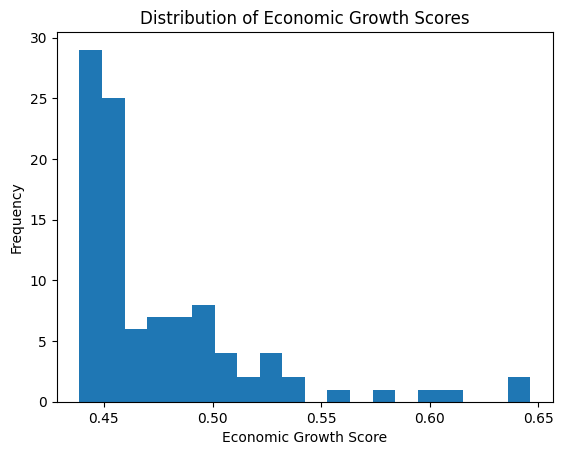

In [59]:
top100["economic_growth_score"].plot(kind="hist", bins=20)

plt.title("Distribution of Economic Growth Scores")
plt.xlabel("Economic Growth Score")

plt.show()

In [60]:
df.to_csv(
    r"C:\Users\renu\Downloads\master_village_dataset.csv",
    index=False
)

top100.to_csv(
    r"C:\Users\renu\Downloads\top100_villages.csv",
    index=False
)

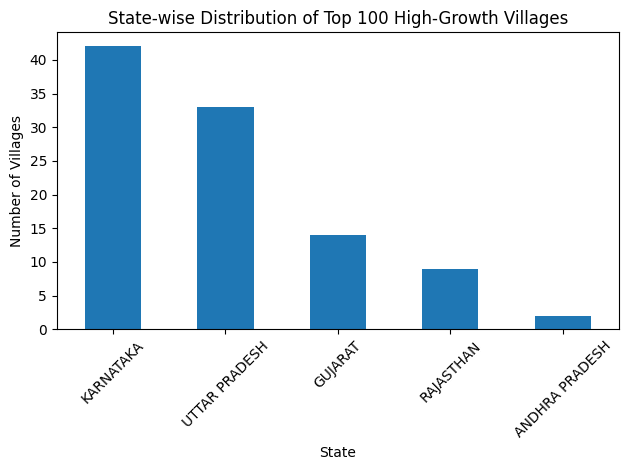

In [61]:
import matplotlib.pyplot as plt

top100["state"].value_counts().plot(kind="bar")

plt.title("State-wise Distribution of Top 100 High-Growth Villages")
plt.xlabel("State")
plt.ylabel("Number of Villages")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

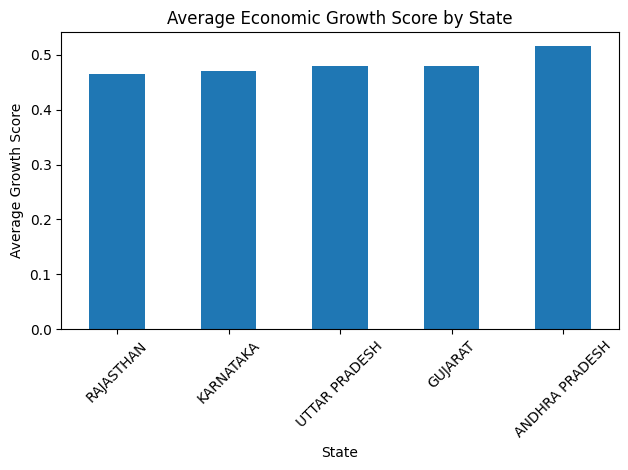

In [62]:
top100.groupby("state")[
    "economic_growth_score"
].mean().sort_values().plot(kind="bar")

plt.title("Average Economic Growth Score by State")
plt.xlabel("State")
plt.ylabel("Average Growth Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

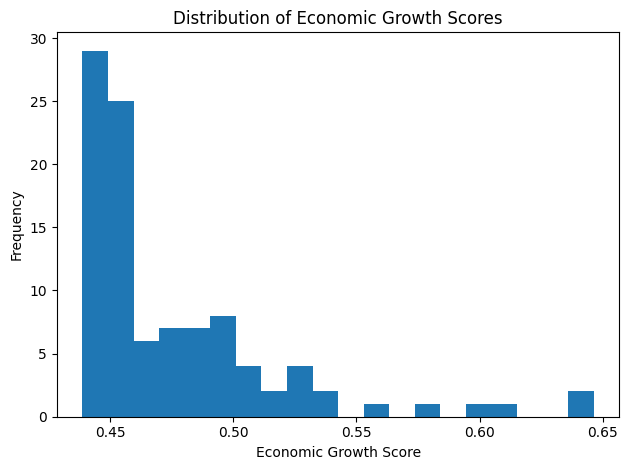

In [63]:
top100["economic_growth_score"].plot(
    kind="hist",
    bins=20
)

plt.title("Distribution of Economic Growth Scores")
plt.xlabel("Economic Growth Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()